--- Loading Data ---

--- Creating 2-Year Survival Target ---
Original Size: 3323
Filtered Size (removing early censored): 2441
Dropped 882 patients censored before 2 years.
Class Balance: Y_2YR
1    0.57968
0    0.42032
Name: proportion, dtype: float64
Features remaining after 1% rarity filter: 58

--- Running Ensemble Feature Selection ---
Selected 41 features out of 58.
Top Features: ['RUNX1', 'ASXL1', 'TET2', 'ASXL2', 'U2AF1', 'BCOR', 'FLT3', 'ANC', 'CTCF', 'PTPN11']...

--- Training Random Forest (Paper's Best Model) ---

--- RESULTS (2-Year OS Prediction) ---
AUROC: 0.8003 (Paper achieved ~0.73)
F1 Score: 0.7543 (Paper achieved ~0.67)

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.63      0.65       103
           1       0.74      0.77      0.75       142

    accuracy                           0.71       245
   macro avg       0.70      0.70      0.70       245
weighted avg       0.71      0.71      0.71       245



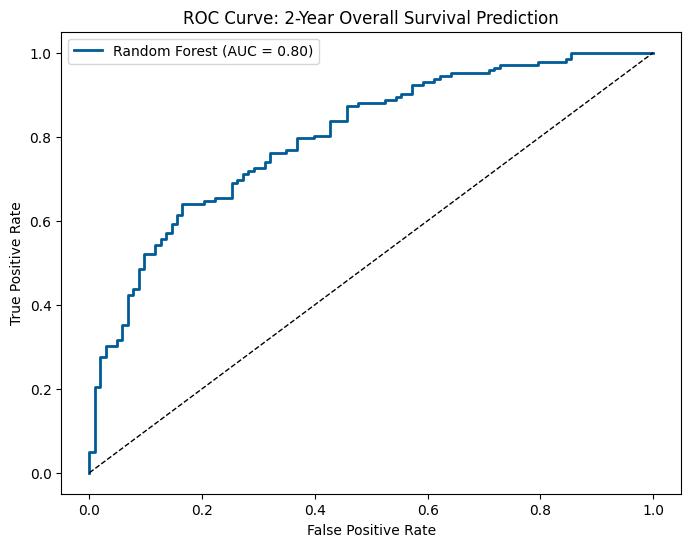

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFE, SelectFromModel, chi2, f_classif
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, roc_curve, classification_report
from sklearn.pipeline import Pipeline


# --- 1. FEATURE ENGINEERING: CYTOGENETICS ---
def parse_cytogenetics(row):
    """
    Parses the text-based CYTOGENETICS column to extract features
    specifically mentioned in the paper: t(8;21), inv(16), del(5), del(17), Complex.
    """
    cyto = str(row).lower()
    features = {
        "cyto_t8_21": 0,
        "cyto_inv16": 0,
        "cyto_del5": 0,
        "cyto_del17": 0,
        "cyto_complex": 0,  # Defined in paper as >= 3 abnormalities
        "cyto_normal": 0,
    }

    # Check for specific translocations/deletions mentioned in paper
    if "t(8;21)" in cyto:
        features["cyto_t8_21"] = 1
    if "inv(16)" in cyto or "t(16;16)" in cyto:
        features["cyto_inv16"] = 1
    if "del(5)" in cyto or "-5" in cyto:
        features["cyto_del5"] = 1
    if "del(17)" in cyto or "-17" in cyto:
        features["cyto_del17"] = 1

    # Heuristic for "Complex" (>3 abnormalities) and "Normal"
    # Counting commas is a rough proxy for number of abnormalities in ISCN notation
    aberration_count = cyto.count(",") + 1
    if "normal" in cyto or "46,xx" in cyto or "46,xy" in cyto:
        if aberration_count <= 1:
            features["cyto_normal"] = 1

    if aberration_count >= 3 and features["cyto_normal"] == 0:
        features["cyto_complex"] = 1

    return pd.Series(features)


# --- 2. DATA PREPARATION ---
def load_and_prep_data():
    print("--- Loading Data ---")
    try:
        clinical = pd.read_csv("../X_train/clinical_train.csv")
        molecular = pd.read_csv("../X_train/molecular_train.csv")
        target = pd.read_csv("../target_train.csv")
    except:
        # Dummy generation for code testing if files missing
        print("Files not found. Generating dummy data for structure testing...")
        clinical = pd.DataFrame(
            {
                "ID": range(200),
                "HB": np.random.rand(200) * 15,
                "WBC": np.random.rand(200) * 20,
                "CYTOGENETICS": "46,XY",
            }
        )
        molecular = pd.DataFrame(
            {
                "ID": np.random.choice(range(200), 400),
                "GENE": np.random.choice(["TP53", "NPM1", "FLT3", "DNMT3A"], 400),
            }
        )
        target = pd.DataFrame(
            {
                "ID": range(200),
                "OS_YEARS": np.random.exponential(3, 200),
                "OS_STATUS": np.random.randint(0, 2, 200),
            }
        )

    # 1. Pivot Molecular Data (One Hot Encoding Genes)
    # The paper treats mutations as binary features
    mol_pivot = pd.crosstab(molecular["ID"], molecular["GENE"]).reset_index()
    # Ensure values are 0 or 1 (in case of multiple mutations in same gene)
    mol_cols = [c for c in mol_pivot.columns if c != "ID"]
    mol_pivot[mol_cols] = (mol_pivot[mol_cols] > 0).astype(int)

    # 2. Extract Cytogenetics
    if "CYTOGENETICS" in clinical.columns:
        cyto_features = clinical["CYTOGENETICS"].apply(parse_cytogenetics)
        clinical = pd.concat([clinical, cyto_features], axis=1)
        # Drop raw text column for ML
        clinical = clinical.drop(columns=["CYTOGENETICS", "CENTER"], errors="ignore")

    # 3. Merge All
    df = clinical.merge(mol_pivot, on="ID", how="left").merge(
        target, on="ID", how="inner"
    )

    # Fill molecular NaNs with 0 (implies no mutation found)
    df[mol_cols] = df[mol_cols].fillna(0)

    return df


# --- 3. TARGET ENGINEERING (The Paper's Logic) ---
def create_binary_target(df):
    """
    Paper Goal: Predict 2-Year Overall Survival.
    Logic:
    - Alive >= 2 Years -> Class 1
    - Dead < 2 Years -> Class 0
    - Censored < 2 Years -> Exclude (Ambiguous status)
    """
    print("\n--- Creating 2-Year Survival Target ---")
    cutoff_years = 2.0

    # Patients we keep
    # 1. Patients who died (Status 1) and Time < 2 (DEFINITELY CLASS 0)
    cond_dead_early = (df["OS_STATUS"] == 1) & (df["OS_YEARS"] < cutoff_years)

    # 2. Patients who lived >= 2 years (Status 0 or 1 doesn't matter, they survived the window) (DEFINITELY CLASS 1)
    cond_survived = df["OS_YEARS"] >= cutoff_years

    # Filter dataset
    valid_indices = cond_dead_early | cond_survived
    df_binary = df.loc[valid_indices].copy()

    # Create Target Y
    df_binary["Y_2YR"] = np.where(df_binary["OS_YEARS"] >= cutoff_years, 1, 0)

    dropped = len(df) - len(df_binary)
    print(f"Original Size: {len(df)}")
    print(f"Filtered Size (removing early censored): {len(df_binary)}")
    print(f"Dropped {dropped} patients censored before 2 years.")
    print(f"Class Balance: {df_binary['Y_2YR'].value_counts(normalize=True)}")

    return df_binary


# --- 4. FEATURE SELECTION (The "Ensemble" Method) ---
def select_features(X, y, feature_names):
    """
    Replicates the paper's 'Multi-stage ML pipeline'.
    Aggregates votes from: Correlation, Chi2, RFE, Lasso, Random Forest.
    """
    print("\n--- Running Ensemble Feature Selection ---")
    # Impute for selection
    imputer = SimpleImputer(strategy="mean")
    X_filled = imputer.fit_transform(X)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_filled)

    votes = np.zeros(X.shape[1])

    # 1. Correlation (Linear)
    correlations = [
        abs(np.corrcoef(X_filled[:, i], y)[0, 1]) for i in range(X.shape[1])
    ]
    correlations = np.nan_to_num(correlations)
    # Top 30 features by correlation
    top_corr = np.argsort(correlations)[-30:]
    votes[top_corr] += 1

    # 2. Chi-Square (Categorical/Positive only) - approximation using F-classif for mixed data
    f_vals, _ = f_classif(X_filled, y)
    f_vals = np.nan_to_num(f_vals)
    top_f = np.argsort(f_vals)[-30:]
    votes[top_f] += 1

    # 3. Recursive Feature Elimination (RFE) with Logistic Regression
    rfe = RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=30)
    rfe.fit(X_scaled, y)
    votes[rfe.support_] += 1

    # 4. Lasso Regularization (L1)
    lasso = LogisticRegression(penalty="l1", solver="liblinear", C=0.1)
    lasso.fit(X_scaled, y)
    votes[lasso.coef_[0] != 0] += 1

    # 5. Random Forest Importance
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_filled, y)
    top_rf = np.argsort(rf.feature_importances_)[-30:]
    votes[top_rf] += 1

    # Threshold: Paper uses a "summed support threshold".
    # Let's keep features with at least 2 votes.
    mask = votes >= 2
    selected_feats = [f for f, m in zip(feature_names, mask) if m]

    print(f"Selected {len(selected_feats)} features out of {len(feature_names)}.")
    print(f"Top Features: {selected_feats[:10]}...")
    return selected_feats


# --- 5. MAIN PIPELINE ---
def main():
    # Load
    df_raw = load_and_prep_data()

    # Create Binary Target
    df_model = create_binary_target(df_raw)

    # Separate X and Y
    drop_cols = ["ID", "OS_YEARS", "OS_STATUS", "Y_2YR"]
    feature_cols = [c for c in df_model.columns if c not in drop_cols]

    X = df_model[feature_cols]
    y = df_model["Y_2YR"]

    # Paper Step: Remove Rare Features (<1%)
    # In binary features (0/1), mean is the frequency
    freq = X.mean()
    keep_cols = freq[freq >= 0.01].index.tolist()
    # Also keep continuous clinical columns even if 'mean' is high/low
    # (Checking if column is boolean first)
    is_bool = X.nunique() <= 2
    continuous_cols = is_bool[~is_bool].index.tolist()
    final_cols = list(set(keep_cols).union(set(continuous_cols)))

    X = X[final_cols]
    print(f"Features remaining after 1% rarity filter: {X.shape[1]}")

    # Train/Test Split (9:1 as per paper)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.1, random_state=42, stratify=y
    )

    # Run Ensemble Feature Selection on TRAINING data only
    selected_features = select_features(X_train, y_train, X_train.columns)
    X_train = X_train[selected_features]
    X_test = X_test[selected_features]

    # --- MODELING (Random Forest - The Winner) ---
    print("\n--- Training Random Forest (Paper's Best Model) ---")

    # Pipeline: Impute -> Scale -> Model
    rf_pipe = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),  # Paper mentions imputation
            ("scaler", StandardScaler()),
            (
                "rf",
                RandomForestClassifier(
                    n_estimators=500,
                    max_depth=10,
                    random_state=42,
                    class_weight="balanced",
                ),
            ),
        ]
    )

    rf_pipe.fit(X_train, y_train)

    # Evaluate
    y_pred = rf_pipe.predict(X_test)
    y_prob = rf_pipe.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)

    print("\n--- RESULTS (2-Year OS Prediction) ---")
    print(f"AUROC: {auc:.4f} (Paper achieved ~0.73)")
    print(f"F1 Score: {f1:.4f} (Paper achieved ~0.67)")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Plot ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.2f})", color="#005b96", lw=2)
    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve: 2-Year Overall Survival Prediction")
    plt.legend()
    plt.show()


if __name__ == "__main__":
    main()